# Backtest Comparison Across All 50 NIFTY Stocks — Alkame-Nifty50

Answers: which sectors show a real, cost-adjusted edge over the NIFTY baseline (per `backtester.py`),
and which don't? Ties back to `SECTOR_MAP` in `config.py`.

This notebook fetches REAL price history via `data_fetcher.py`. Expect this notebook to take several
minutes to run, since it's making real yfinance calls and training real models.

In [2]:
import sys
import time
import os
from pathlib import Path

# Repo root importable from inside notebooks/
sys.path.insert(0, str(Path.cwd().parent.parent))

import matplotlib.pyplot as plt
import pandas as pd

from config import NIFTY50_SYMBOLS, SECTOR_MAP, to_yfinance_ticker
from data_fetcher import DataFetcher
from backtester import Backtester

# Ensure figures folder exists right away
os.makedirs("../figures", exist_ok=True)

# Start with a small subset while developing — swap to NIFTY50_SYMBOLS for full run
SYMBOLS_TO_BACKTEST = ["RELIANCE", "TCS", "HDFCBANK", "INFY", "TATASTEEL", "SUNPHARMA",
                       "ITC", "MARUTI", "COALINDIA", "WIPRO"]

data_fetcher = DataFetcher()
backtester = Backtester()

In [3]:
index_df = data_fetcher.fetch_nifty_index()
assert index_df is not None and not index_df.empty, "Could not fetch NIFTY index data — check connection."

symbol_data = {}
for symbol in SYMBOLS_TO_BACKTEST:
    yf_ticker = to_yfinance_ticker(symbol)
    stock_df = data_fetcher.fetch_ohlcv(yf_ticker)
    if stock_df is None or stock_df.empty:
        print(f"  Skipping {symbol} — no data available.")
        continue
    symbol_data[symbol] = (stock_df, index_df)
    print(f"  Fetched {symbol}: {len(stock_df)} bars")
    time.sleep(0.5)  # Polite delay for yfinance API rate limiting

print(f"\nFetched data for {len(symbol_data)}/{len(SYMBOLS_TO_BACKTEST)} symbols. Running backtests...")
results = backtester.run_backtest_for_all_symbols(symbol_data)
print(f"Backtested {len(results)} symbols.")

  Fetched RELIANCE: 4275 bars
  Fetched TCS: 4275 bars
  Fetched HDFCBANK: 4275 bars
  Fetched INFY: 4275 bars
  Fetched TATASTEEL: 4275 bars
  Fetched SUNPHARMA: 4275 bars
  Fetched ITC: 4275 bars
  Fetched MARUTI: 4275 bars
  Fetched COALINDIA: 4275 bars
  Fetched WIPRO: 4275 bars

Fetched data for 10/10 symbols. Running backtests...
Backtested 10 symbols.


In [4]:
rows = []
for symbol, r in results.items():
    rows.append({
        "symbol": symbol,
        "sector": SECTOR_MAP.get(symbol, "Other"),
        "success": r.success,
        "n_test_predictions": r.n_test_predictions,
        "n_trades_taken": r.n_trades_taken,
        "strategy_return_pct": r.strategy_cumulative_return_pct,
        "baseline_return_pct": r.baseline_cumulative_return_pct,
        "alpha_pct": r.alpha_pct,
        "edge_check_status": r.edge_check_status,
        "calibration_status": r.calibration_status,
        "calibration_ece": r.calibration_ece,
        "is_live_worthy": r.is_live_worthy,
        "error": r.error,
    })

results_df = pd.DataFrame(rows)
results_df.sort_values("alpha_pct", ascending=False)

,symbol,sector,success,n_test_predictions,n_trades_taken,strategy_return_pct,baseline_return_pct,alpha_pct,edge_check_status,calibration_status,calibration_ece,is_live_worthy,error
4,TATASTEEL,Metals,True,828,105,11.755940,4.394986,7.360953,EDGE_CONFIRMED,SUFFICIENT,0.031353,True,None
0,RELIANCE,Energy,True,828,149,6.576676,4.271361,2.305315,EDGE_CONFIRMED,SUFFICIENT,0.025047,True,None
6,ITC,FMCG,True,828,47,1.545123,4.276239,-2.731117,NO_EDGE,SUFFICIENT,0.062210,False,None
9,WIPRO,IT,True,828,288,-2.467372,4.372843,-6.840214,NO_EDGE,SUFFICIENT,0.029670,False,None
3,INFY,IT,True,828,413,-8.927540,4.276239,-13.203779,NO_EDGE,SUFFICIENT,0.034058,False,None
2,HDFCBANK,Banking,True,828,217,-13.087448,4.276239,-17.363687,NO_EDGE,SUFFICIENT,0.016745,False,None
7,MARUTI,Auto,True,828,268,-21.848707,4.372843,-26.221549,NO_EDGE,SUFFICIENT,0.005494,False,None
5,SUNPHARMA,Pharma,True,828,572,-36.569979,4.394986,-40.964966,NO_EDGE,SUFFICIENT,0.140204,False,None
1,TCS,IT,True,828,428,-36.798188,4.276239,-41.074428,NO_EDGE,SUFFICIENT,0.031283,False,None
8,COALINDIA,Energy,True,828,544,-37.745512,4.276239,-42.021752,NO_EDGE,SUFFICIENT,0.155121,False,None


## Which sectors actually show an edge?

In [5]:
successful_df = results_df[results_df["success"]].copy()

sector_alpha = (
    successful_df.groupby("sector")
    .agg(
        n_stocks=("symbol", "count"),
        mean_alpha_pct=("alpha_pct", "mean"),
        pct_edge_confirmed=("edge_check_status", lambda s: (s == "EDGE_CONFIRMED").mean() * 100),
        pct_live_worthy=("is_live_worthy", lambda s: s.mean() * 100),
    )
    .sort_values("mean_alpha_pct", ascending=False)
)
sector_alpha

,n_stocks,mean_alpha_pct,pct_edge_confirmed,pct_live_worthy
sector,,,,
Metals,1,7.360953,100.0,100.0
FMCG,1,-2.731117,0.0,0.0
Banking,1,-17.363687,0.0,0.0
Energy,2,-19.858218,50.0,50.0
IT,3,-20.372807,0.0,0.0
Auto,1,-26.221549,0.0,0.0
Pharma,1,-40.964966,0.0,0.0


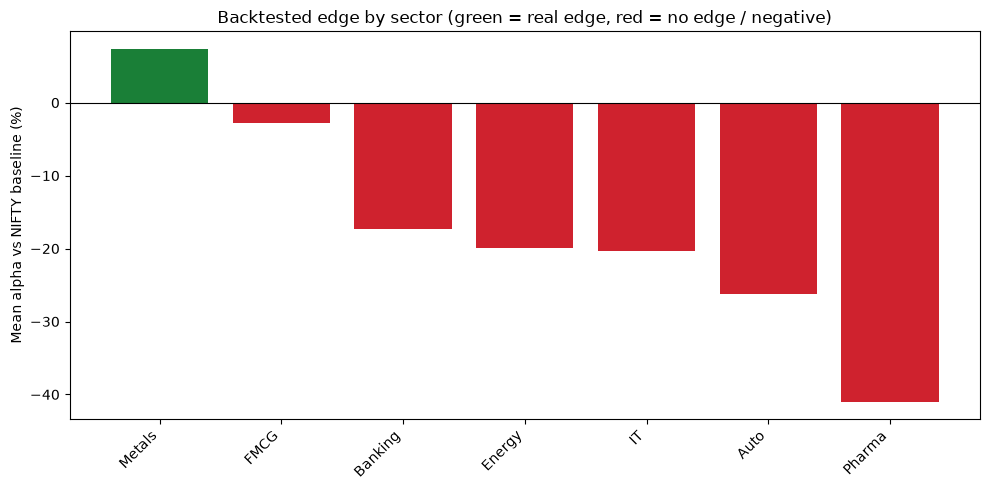

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#1a7f37" if v > 0 else "#cf222e" for v in sector_alpha["mean_alpha_pct"]]
ax.bar(sector_alpha.index, sector_alpha["mean_alpha_pct"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Mean alpha vs NIFTY baseline (%)")
ax.set_title("Backtested edge by sector (green = real edge, red = no edge / negative)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/sector_alpha_bar_chart.png", dpi=150)
plt.show()

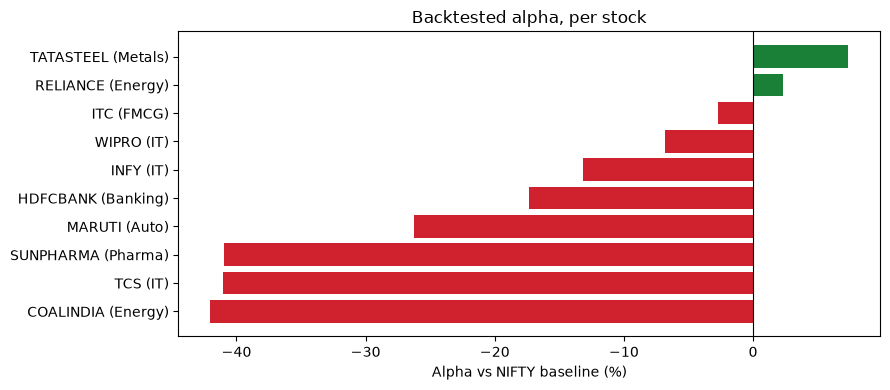

In [7]:
fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(successful_df))))
plot_df = successful_df.sort_values("alpha_pct")
colors = ["#1a7f37" if v > 0 else "#cf222e" for v in plot_df["alpha_pct"]]
ax.barh(plot_df["symbol"] + " (" + plot_df["sector"] + ")", plot_df["alpha_pct"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Alpha vs NIFTY baseline (%)")
ax.set_title("Backtested alpha, per stock")
plt.tight_layout()
plt.savefig("../figures/per_stock_alpha_chart.png", dpi=150)
plt.show()

## Findings

*(Analyze the generated graphics. Identify which specific sectors show positive cost-adjusted alphas, and note any high-conviction live-worthy stocks.)*